In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer 


In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [4]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\zhass\AppData\Local\Temp\ipykernel_12336\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [6]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [5]:
x = df.iloc[:,1:]
y = df.iloc[:,:1]


In [6]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

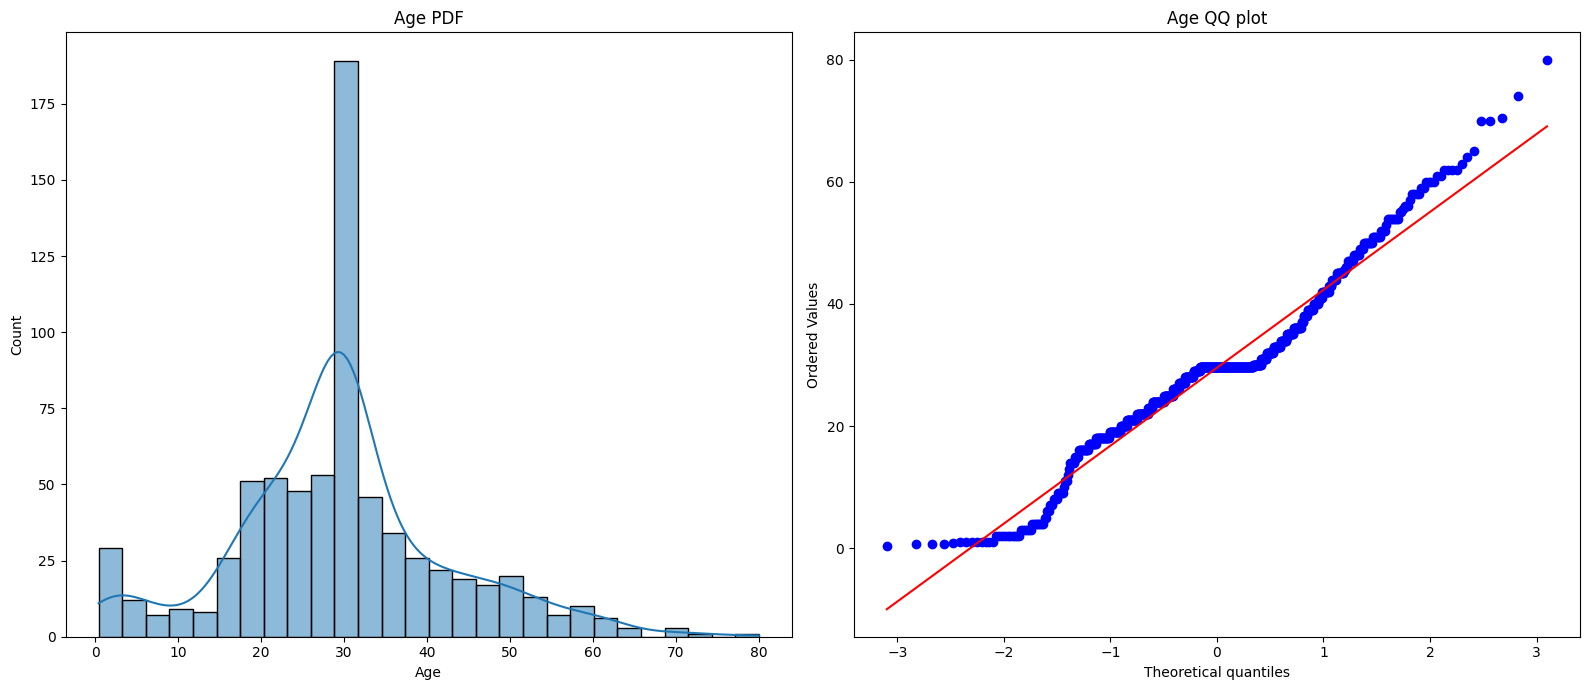

In [9]:
plt.figure(figsize=(16,7))
plt.subplot(1,2,1)
sns.histplot(x_train['Age'],kde = True)
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(x_train['Age'],dist="norm",plot=plt)
plt.title('Age QQ plot')
plt.tight_layout()
plt.show()

In [13]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [16]:
clf1.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred1 = clf1.predict(x_test)
y_pred2 = clf2.predict(x_test)

print("lg accuracy ",accuracy_score(y_test,y_pred1))
print("DTC accuracy ",accuracy_score(y_test,y_pred2))

lg accuracy  0.6480446927374302
DTC accuracy  0.6871508379888268


c:\Users\zhass\miniconda3\envs\python_env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [17]:
trf = FunctionTransformer(func=np.log1p)

In [18]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.fit_transform(x_test)

In [19]:
clf1.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred1 = clf1.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print("lg accuracy ",accuracy_score(y_test,y_pred1))
print("DTC accuracy ",accuracy_score(y_test,y_pred2))

lg accuracy  0.6815642458100558
DTC accuracy  0.6759776536312849


c:\Users\zhass\miniconda3\envs\python_env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
